In [106]:
#pip install yfinance


In [1]:
#pip install nsepy

In [1]:
from Univariate import Univariate
from Univariate import central_tendency_percentile

In [2]:
obj=Univariate()
ctp=central_tendency_percentile()

In [12]:
import yfinance as yf
import datetime as dt
symbol = "TATACONSUM.NS"
start = dt.datetime(2025,6,1)
end = dt.datetime(2026,1,5)
dataset = yf.download(symbol, start=start, end=end)
print(dataset)

[*********************100%***********************]  1 of 1 completed

Price              Close          High           Low          Open  \
Ticker     TATACONSUM.NS TATACONSUM.NS TATACONSUM.NS TATACONSUM.NS   
Date                                                                 
2025-06-02   1120.400024   1125.000000   1099.199951   1100.000000   
2025-06-03   1114.599976   1123.199951   1110.099976   1116.099976   
2025-06-04   1124.400024   1125.900024   1110.000000   1110.000000   
2025-06-05   1111.900024   1127.099976   1108.199951   1124.500000   
2025-06-06   1115.599976   1123.900024   1109.400024   1111.900024   
...                  ...           ...           ...           ...   
2025-12-29   1195.199951   1200.900024   1170.500000   1174.000000   
2025-12-30   1179.000000   1201.800049   1171.099976   1200.699951   
2025-12-31   1192.000000   1195.099976   1172.599976   1179.000000   
2026-01-01   1176.900024   1195.500000   1173.300049   1192.000000   
2026-01-02   1170.699951   1185.699951   1168.400024   1176.900024   

Price             V

In [13]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 149 entries, 2025-06-02 to 2026-01-02
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   (Close, TATACONSUM.NS)   149 non-null    float64
 1   (High, TATACONSUM.NS)    149 non-null    float64
 2   (Low, TATACONSUM.NS)     149 non-null    float64
 3   (Open, TATACONSUM.NS)    149 non-null    float64
 4   (Volume, TATACONSUM.NS)  149 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 7.0 KB


In [14]:
dataset

Price,Close,High,Low,Open,Volume
Ticker,TATACONSUM.NS,TATACONSUM.NS,TATACONSUM.NS,TATACONSUM.NS,TATACONSUM.NS
Date,,,,,
2025-06-02,1120.400024,1125.000000,1099.199951,1100.000000,907133
2025-06-03,1114.599976,1123.199951,1110.099976,1116.099976,795876
2025-06-04,1124.400024,1125.900024,1110.000000,1110.000000,635699
2025-06-05,1111.900024,1127.099976,1108.199951,1124.500000,1044950
2025-06-06,1115.599976,1123.900024,1109.400024,1111.900024,503186
...,...,...,...,...,...
2025-12-29,1195.199951,1200.900024,1170.500000,1174.000000,1806020
2025-12-30,1179.000000,1201.800049,1171.099976,1200.699951,2256987


In [15]:
quan = dataset.select_dtypes(include=['float64','int64']).columns

In [16]:
des_data = ctp.MMM_per_IQR(dataset, quan)
des_data

Price,Close,High,Low,Open,Volume
Ticker,TATACONSUM.NS,TATACONSUM.NS,TATACONSUM.NS,TATACONSUM.NS,TATACONSUM.NS
Mean,1121.863763,1132.187253,1110.290599,1120.840942,1156544.644295
Median,1120.0,1127.099976,1110.0,1117.0,963508.0
Mode,1052.800049,1062.900024,1080.0,1085.0,123219
Q1:25%,1085.099976,1095.800049,1075.300049,1085.0,699541.0
Q2:50%,1120.0,1127.099976,1110.0,1117.0,963508.0
Q3:75%,1162.0,1173.099976,1146.800049,1159.800049,1299596.0
99%,1193.663975,1201.368037,1172.964014,1196.056025,4091322.48
Q4:100%,1197.5,1202.800049,1174.099976,1200.699951,6264546
IQR,76.900024,77.299927,71.5,74.800049,600055.0


In [17]:
des_data["Low"]

Ticker,TATACONSUM.NS
Mean,1110.290599
Median,1110.0
Mode,1080.0
Q1:25%,1075.300049
Q2:50%,1110.0
Q3:75%,1146.800049
99%,1172.964014
Q4:100%,1174.099976
IQR,71.5
1.5rule,107.25


In [18]:
des_data["High"]

Ticker,TATACONSUM.NS
Mean,1132.187253
Median,1127.099976
Mode,1062.900024
Q1:25%,1095.800049
Q2:50%,1127.099976
Q3:75%,1173.099976
99%,1201.368037
Q4:100%,1202.800049
IQR,77.299927
1.5rule,115.94989


In [19]:
import numpy as np

In [20]:
np.percentile(dataset["Low"],99)

1172.964013671875

In [21]:
def get_pdf_probability(dataset,startrange,endrange):
    from matplotlib import pyplot
    from scipy.stats import norm
    import seaborn as sns
    ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')
    pyplot.axvline(startrange,color='Red')
    pyplot.axvline(endrange,color='Red')
    # generate a sample
    sample = dataset
    # calculate parameters
    sample_mean =sample.mean()
    sample_std = sample.std()
    print('Mean=%.3f, Standard Deviation=%.3f' % (sample_mean, sample_std))
    # define the distribution
    dist = norm(sample_mean, sample_std)
    
    # sample probabilities for a range of outcomes
    values = [value for value in range(startrange, endrange)]
    probabilities = [dist.pdf(value) for value in values]    
    prob=sum(probabilities)
    print("The area between range({},{}):{}".format(startrange,endrange,sum(probabilities)))
    return prob
    

Mean=1110.291, Standard Deviation=40.478
The area between range(219,230):[2.75391609e-105]


C:\Users\Windows\AppData\Local\Temp\ipykernel_18512\2842244316.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')
C:\Users\Windows\AppData\Local\Temp\ipykernel_18512\2842244316.py:13: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print('Mean=%.3f, Standard Deviation=%.3f' % (sample_mean, sample_std))


array([2.75391609e-105])

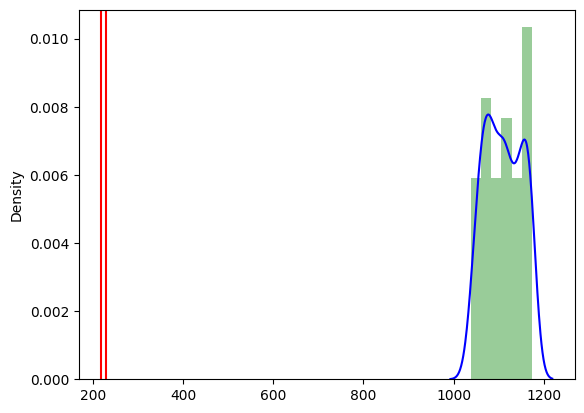

In [22]:
get_pdf_probability(dataset["Low"],219,230)

In [42]:
def stdNBgraph(dataset):
        # Coverted to standard Normal Distribution
    import seaborn as sns

    # Vectorized calculation (much faster than a loop!)
    z_score = (dataset - dataset.mean()) / dataset.std()
    
    # Plotting
    sns.histplot(z_score, kde=True) # sns.distplot is deprecated, use histplot
    
    return z_score.mean()
    #z_score.std()


Ticker
TATACONSUM.NS    2.384372e-16
dtype: float64

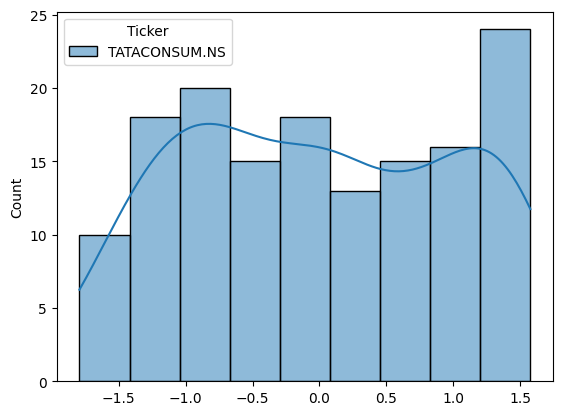

In [43]:
stdNBgraph(dataset["Low"])

In [46]:
def freqTable(columnName, dataset):
    import pandas as pd
    
    # 1. Get the value counts once to avoid redundant calculation
    counts = dataset[columnName].value_counts()
    
    # 2. Create the DataFrame
    frq = pd.DataFrame()
    
    # 3. Use .index.tolist() to avoid the MultiIndex error
    frq["Unique_Values"] = counts.index.tolist()
    frq["Frequency"] = counts.values
    
    # 4. Perform calculations using the local 'counts' variable
    frq["Relative_Fre"] = (counts.values / len(dataset[columnName])) * 100
    frq["Cumulative"] = frq["Relative_Fre"].cumsum()
    
    return frq

In [47]:
freqTable("Low",dataset)

,Unique_Values,Frequency,Relative_Fre,Cumulative
0,"(1080.0,)",3,2.013423,2.013423
1,"(1086.5,)",2,1.342282,3.355705
2,"(1065.5,)",2,1.342282,4.697987
3,"(1090.5999755859375,)",2,1.342282,6.040268
4,"(1060.0,)",2,1.342282,7.382550
...,...,...,...,...
130,"(1082.0,)",1,0.671141,97.315436
131,"(1081.699951171875,)",1,0.671141,97.986577
132,"(1080.0999755859375,)",1,0.671141,98.657718
133,"(1079.0999755859375,)",1,0.671141,99.328859


In [48]:
freqTable("High",dataset)

,Unique_Values,Frequency,Relative_Fre,Cumulative
0,"(1085.0,)",2,1.342282,1.342282
1,"(1126.699951171875,)",2,1.342282,2.684564
2,"(1154.199951171875,)",2,1.342282,4.026846
3,"(1150.0,)",2,1.342282,5.369128
4,"(1077.5,)",2,1.342282,6.711409
...,...,...,...,...
134,"(1106.5999755859375,)",1,0.671141,97.315436
135,"(1105.800048828125,)",1,0.671141,97.986577
136,"(1105.5999755859375,)",1,0.671141,98.657718
137,"(1105.4000244140625,)",1,0.671141,99.328859


In [49]:
fh=freqTable("High",dataset)

In [50]:
fh.sort_values(by="Frequency",ascending=False)

,Unique_Values,Frequency,Relative_Fre,Cumulative
0,"(1085.0,)",2,1.342282,1.342282
6,"(1165.800048828125,)",2,1.342282,9.395973
1,"(1126.699951171875,)",2,1.342282,2.684564
9,"(1089.9000244140625,)",2,1.342282,13.422819
7,"(1062.9000244140625,)",2,1.342282,10.738255
...,...,...,...,...
46,"(1195.0999755859375,)",1,0.671141,38.255034
45,"(1195.5,)",1,0.671141,37.583893
44,"(1199.800048828125,)",1,0.671141,36.912752
43,"(1200.9000244140625,)",1,0.671141,36.241611


In [51]:
fhs=fh[fh["Frequency"]==2]["Unique_Values"].sort_values(ascending=False)

In [52]:
fhs

5                (1187.0,)
6     (1165.800048828125,)
2     (1154.199951171875,)
3                (1150.0,)
1     (1126.699951171875,)
8                (1103.0,)
9    (1089.9000244140625,)
0                (1085.0,)
4                (1077.5,)
7    (1062.9000244140625,)
Name: Unique_Values, dtype: object